# Post mofa-flex analysis

### Contents:

1. [Load models (Normal, SnS, and GP).](#load-models)

2. [MOFA-Flex model result overview.](#mofa-flex-results-overview)
<br>
2.1 [Factor correlation and variance explained.](#1-variance-explained)
<br>
2.2 [Average R2.](#2-average-r2)
<br>
2.3 [Weights distribution.](#3weights-dist)
<br>
2.4 [Heatmap (view x LR).](#4-heatmap-view-x-lr)

3. [DR and clustering.](#dr-using-factors-values)

4. [Regression Model.](#regression-model)
<br>
4.1 [Evaluate model.](#evaluate-the-model)
<br>
4.2 [AUC.](#auc)

5. [Map clusters to spatial.](#map-clusters-to-spatial)

In [1]:
import os.path
import anndata as ad
import mudata as md
import numpy as np
import pandas as pd
import mofaflex as mfl
from plotnine import *
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from umap import UMAP
from sklearn.manifold import TSNE

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



# Load models

### Normal

In [2]:
models_path = Path("/g/stegle/aalsayah/repos/data/models_obj")

In [3]:
model= mfl.MOFAFLEX.load(models_path / 'crc_231.hdf5')

WARNING	The stored model was created with a different version of MOFA-FLEX. Some features may not work.


### SnS

In [ ]:
#model = mfl.MOFAFLEX.load(models_path / "sns_models/crc_110/Normal.SnS/crc_110.Normal.SnS.hdf5")

WARNING	The stored model was created with a different version of MOFA-FLEX. Some features may not work.


### GP

In [ ]:
#model = mfl.MOFAFLEX.load(models_path / "GP_models/crc_232_no_mye_IgM/GP.Normal/crc_232_no_mye_IgM.GP.Normal.hdf5")

# MOFA-Flex results overview

## 1. Variance Explained

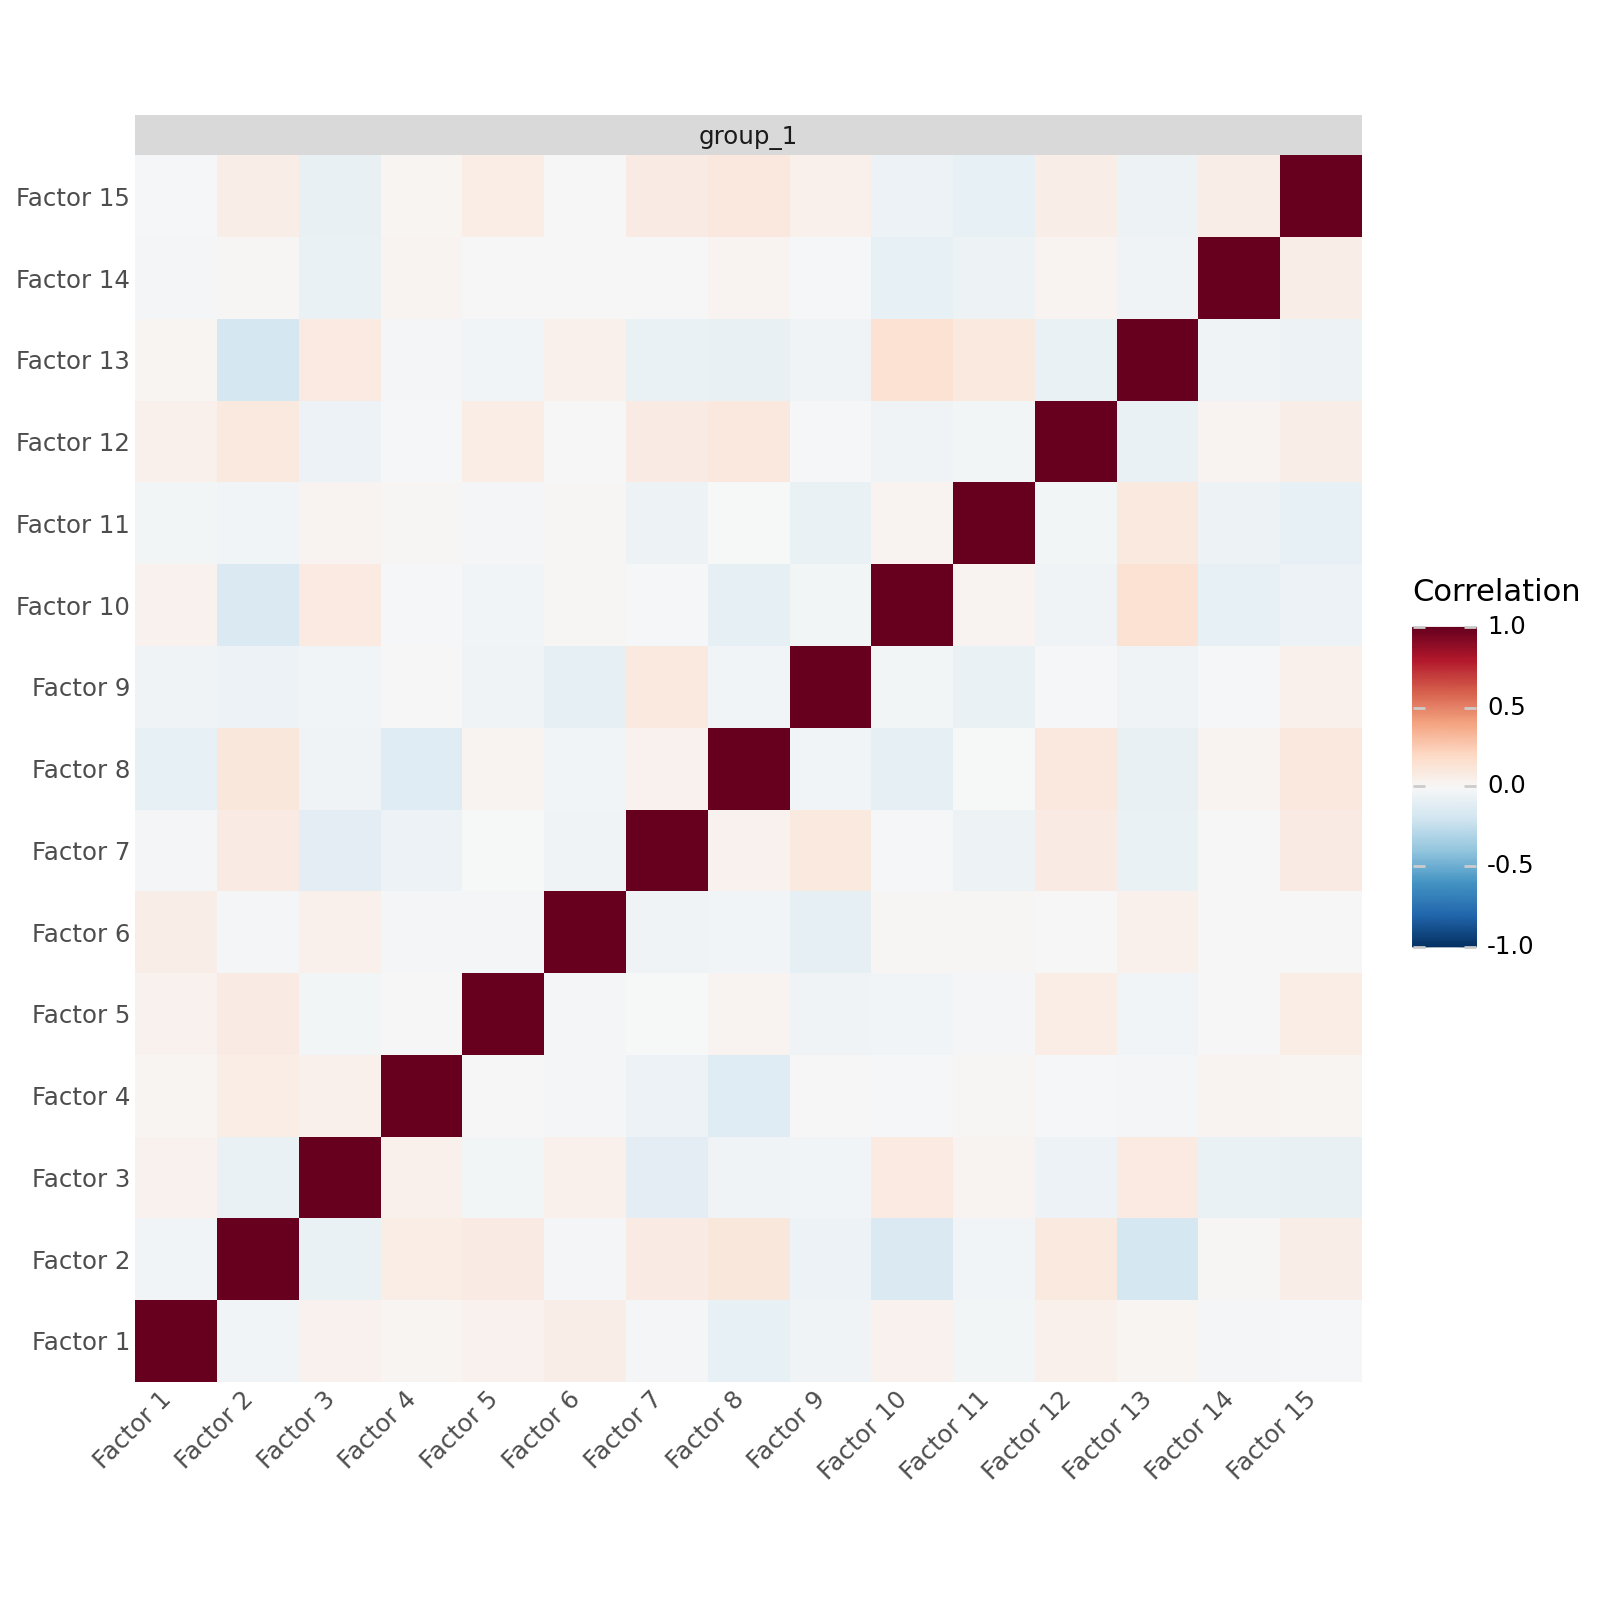

In [4]:
mfl.pl.factor_correlation(model)

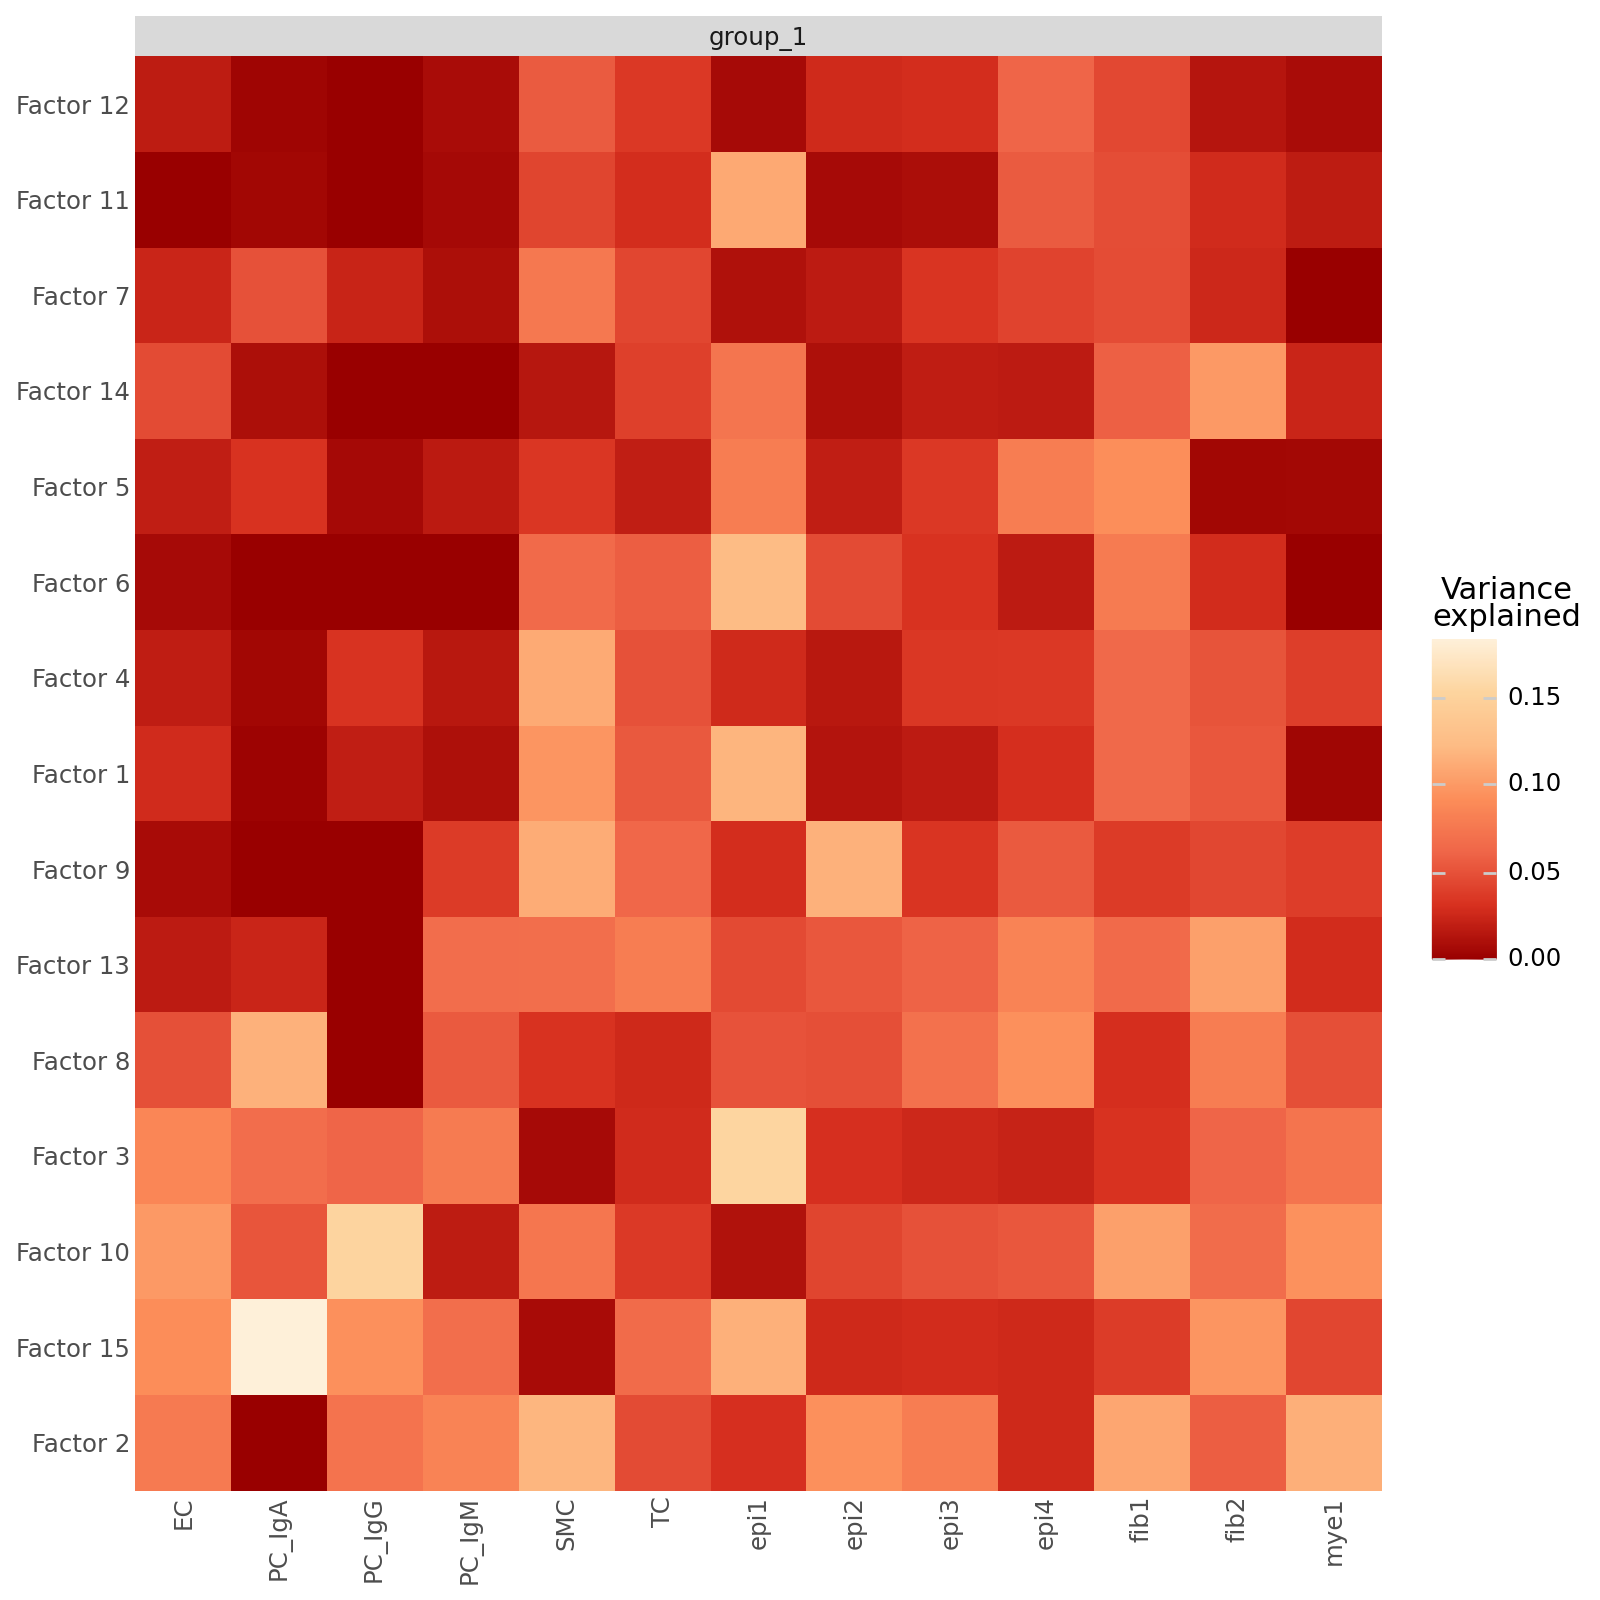

In [5]:
mfl.pl.variance_explained(model, figsize= (8,8))

## 2. Average R2

In [6]:
print(model.get_r2(total=True))

         group_1
epi1    0.766170
epi2    0.508647
epi4    0.670584
epi3    0.516655
EC      0.682890
mye1    0.498224
fib2    0.682946
PC_IgG  0.689487
PC_IgA  0.642853
TC      0.642932
PC_IgM  0.497279
fib1    0.773638
SMC     0.772149


In [7]:
r2 = model.get_r2(total=True)
r2["group_1"].mean()

0.6418810845228199

## 3.Weights dist

In [8]:
weights_dict= model.get_weights()

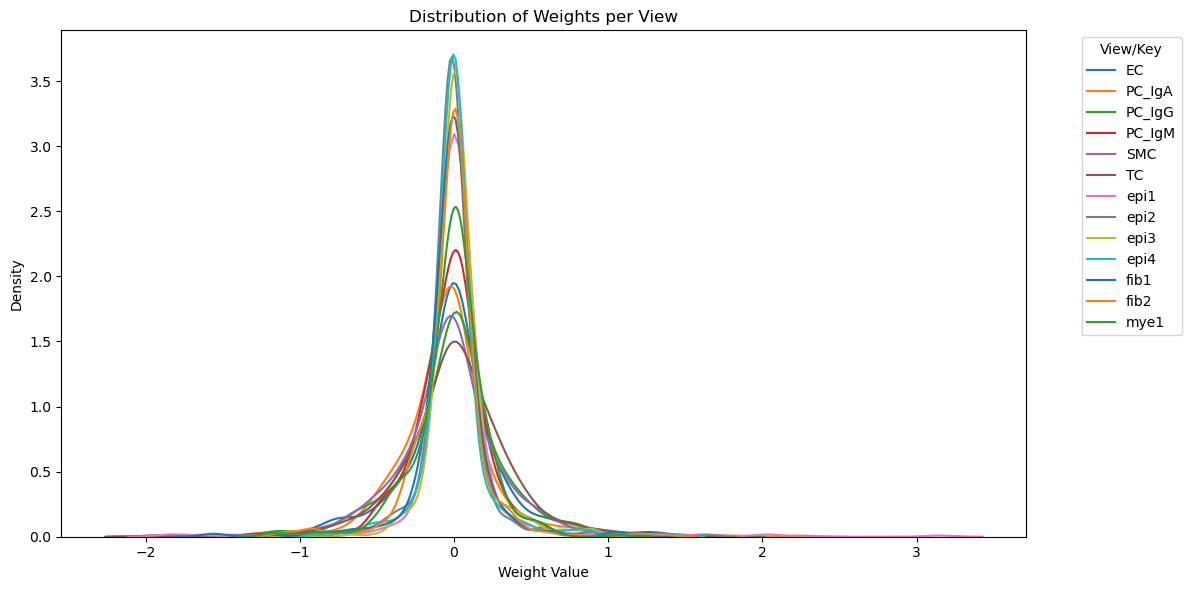

In [9]:
plt.figure(figsize=(12, 6))

# Loop through each view/key
for key, df in weights_dict.items():
    # Flatten all weights from that DataFrame into 1D array
    values = df.values.flatten()
    sns.kdeplot(values, label=key, fill=False)  # distribution curve

plt.title("Distribution of Weights per View")
plt.xlabel("Weight Value")
plt.ylabel("Density")
plt.legend(title="View/Key", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
#mfl.pl.all_weights(model_gp, views=['fib2'], figsize=(8,8), show_featurenames=True)
#mfl.pl.weights(model, n_features=10, views=["fib2"], factors=1, pointsize=2, figsize=(8,8))
#mfl.pl.top_weights(model, n_features=15, views="fib2", factors=1)

## 4. Heatmap (view x LR)

In [11]:
from string import ascii_uppercase
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

In [12]:
weights = model.get_weights()

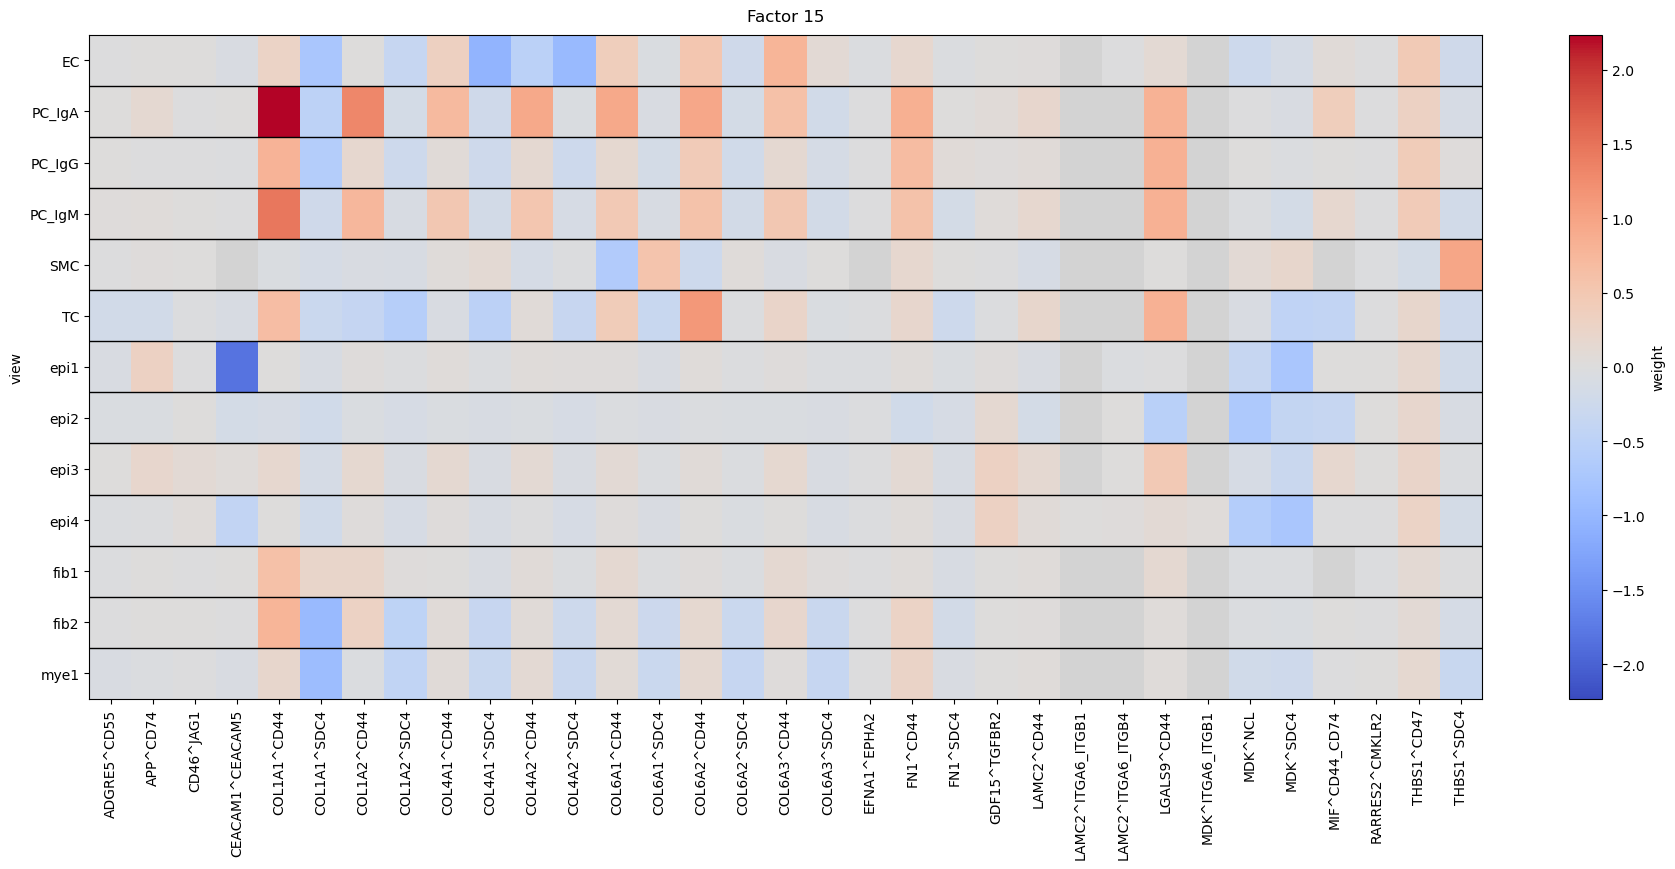

In [13]:
import re
from matplotlib.colors import TwoSlopeNorm

# choose the factor you want:
factor = 15

def resolve_factor_label(df, factor):
    """
    Return the exact row label in df.index for a given factor selector.
    Accepts: 3, "3", "Factor 3", "factor 03", etc.
    """
    idx_map = {str(idx).strip().lower(): idx for idx in df.index}
    key = str(factor).strip().lower()
    # exact match first
    if key in idx_map:
        return idx_map[key]
    # otherwise pull the first integer and try "Factor {n}"
    m = re.search(r'\d+', key)
    if m:
        candidate = f"factor {int(m.group())}"
        if candidate in idx_map:
            return idx_map[candidate]
    raise KeyError(f"Couldn't find factor '{factor}'. Available: {list(df.index)}")

rows, labels = [], []
for view, df in weights.items():
    row_label = resolve_factor_label(df, factor)
    s = df.loc[row_label].copy()
    s.index = ['^'.join(c.split('^')[1:]) for c in s.index]  # drop prefix before first ^
    rows.append(s)
    labels.append(view)

# assemble matrix (align columns across views)
all_cols = sorted({c for s in rows for c in s.index})
X = pd.DataFrame([s.reindex(all_cols) for s in rows], index=labels)

plt.figure(figsize=(0.5*X.shape[1] + 2, 0.6*X.shape[0] + 1))

# zero-centered diverging colormap
v = np.nanmax(np.abs(X.values))
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
cmap = plt.get_cmap('coolwarm').copy()
cmap.set_bad('lightgray')  # NaNs

im = plt.imshow(np.ma.masked_invalid(X.values),
                aspect='auto', interpolation='nearest',
                cmap=cmap, norm=norm)

plt.yticks(range(X.shape[0]), X.index)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.ylabel("view")
plt.colorbar(im, label="weight")
for r in range(1, X.shape[0]):
    plt.axhline(r - 0.5, color='black', lw=1)
plt.title(f"Factor {factor}", pad=10)  # shows "Factor 3" if you passed 3
plt.tight_layout()
plt.show()


# DR using factors values

In [14]:
factors = model.get_factors()
factors = factors["group_1"]

In [15]:
factors

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
c_3_2_8,0.243629,-0.543986,0.677211,0.038135,-0.966604,0.302325,-0.316709,-0.099508,-0.196328,-0.530806,0.265569,-0.225680,0.363704,0.016120,-0.240489
c_3_2_84,0.876591,-0.812694,-1.093564,-1.522231,-0.950914,0.096975,1.693754,-0.213873,-0.025781,-0.089149,-0.501557,0.503744,-0.772494,0.204690,-0.333905
c_3_3_115,-0.308965,-0.618498,0.247386,0.030165,-0.394708,-0.086766,-0.035858,-0.213286,0.254227,0.085937,-0.055643,-0.243201,0.333368,0.364338,-0.164413
c_3_3_990,-0.074650,0.262502,-0.462475,0.107814,-0.548826,-0.332848,0.139974,0.855108,0.431920,-0.354177,0.261777,-0.144934,-0.189039,0.031771,0.220235
c_3_3_993,-0.149703,-0.033420,-0.247248,0.282983,-0.224770,-0.017600,0.228554,0.065810,0.087759,-0.009643,-0.232527,-0.241847,0.048580,0.027608,0.419893
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_3_78_984,1.187680,1.143005,-0.765436,0.256072,-0.153651,0.594271,-0.050202,-0.299956,-0.640248,-1.097584,-0.866858,1.112417,-0.345671,-0.012349,0.774628
c_3_79_533,-0.076026,0.141517,0.294098,-0.226709,-0.379762,-0.412407,0.260782,0.087129,0.478656,0.254669,0.170116,0.481027,0.325688,0.258616,-0.021726
c_3_79_719,-0.233196,1.128684,-0.286898,0.623154,-1.315492,0.857664,0.059354,0.268418,-0.561050,-0.418783,-0.322838,1.002208,-0.174260,1.076413,0.296087
c_3_94_712,-0.097940,-0.083130,-0.117940,-0.027263,-0.037224,-0.325817,0.013873,0.066676,0.735488,0.076153,0.433460,0.132757,0.185580,-0.019643,-0.194149


### Load lrdata

In [17]:
data_path = Path("/g/stegle/aalsayah/repos/data/lrdata_processed")
lrdata = sc.read_h5ad(data_path/ "crc_231_lrdata.h5ad")

In [18]:
lv1 = lrdata.obs["lv1"]
lv2 = lrdata.obs["lv2"]
ist = lrdata.obs["ist"]
typ = lrdata.obs["typ"]

In [19]:
lv1 = lv1.loc[lv1.index.intersection(factors.index)]
lv1 = lv1.reindex(factors.index)
lv1.shape

(43372,)

## UMAP

In [20]:
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler
import hdbscan

In [21]:
# --- Standardize ---
scaler = StandardScaler()
X = scaler.fit_transform(factors)

### higher-D

In [22]:
# --- UMAP for clustering (higher-D) ---
umap_clusters = umap.UMAP(
    n_components=10,
    n_neighbors=50,         
    min_dist=0.2,           
    metric="euclidean",      
    random_state=42
).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [23]:
# --- HDBSCAN: start conservative ---
n = X.shape[0]
mcs = max(30, int(np.sqrt(n)))  
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=mcs,
    min_samples=None,               
    cluster_selection_method="eom",  
    cluster_selection_epsilon=0.05  
).fit(umap_clusters)

labels = clusterer.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_rate = (labels == -1).mean()
print(f"clusters={n_clusters}, noise={noise_rate:.2%}")

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


clusters=9, noise=29.69%


#### 2D UMAP

In [24]:
# --- 2D UMAP for visualization only ---
umap2 = umap.UMAP(
    n_components=2,
    n_neighbors=50,
    min_dist=0.2,
    metric="euclidean",
    random_state=42
).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [25]:
df_umap = pd.DataFrame(umap2, columns=['UMAP1','UMAP2'], index=factors.index)
df_umap['Cluster'] = labels
df_umap['Conf'] = clusterer.probabilities_  # how confident each assignment is

#### Plot UMAP

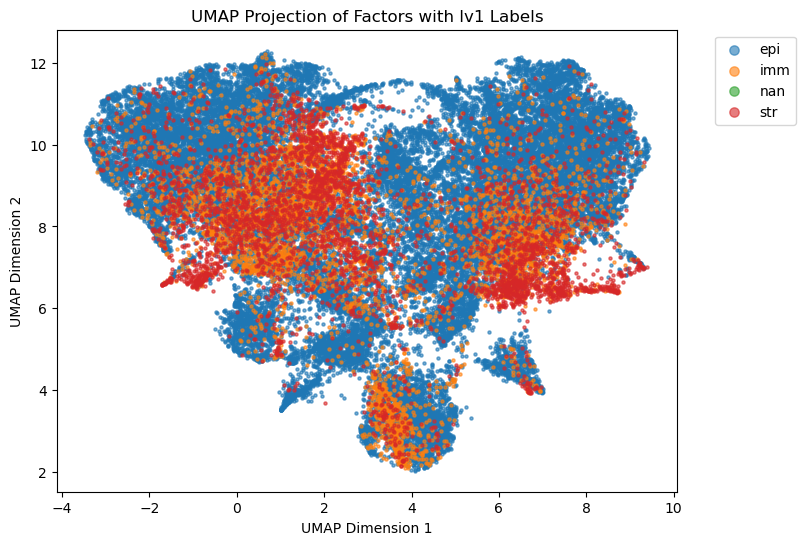

In [26]:
df_umap['Label'] = lv1.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors with lv1 Labels")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

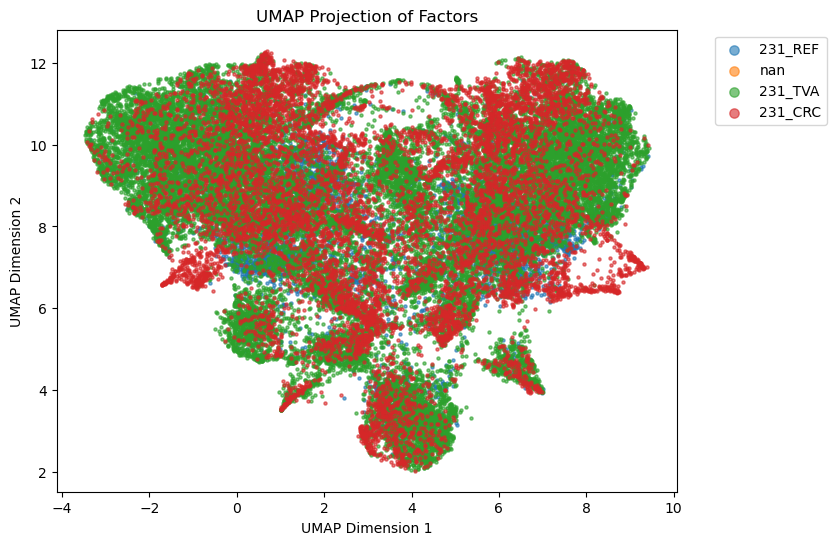

In [27]:
df_umap['Label'] = typ.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

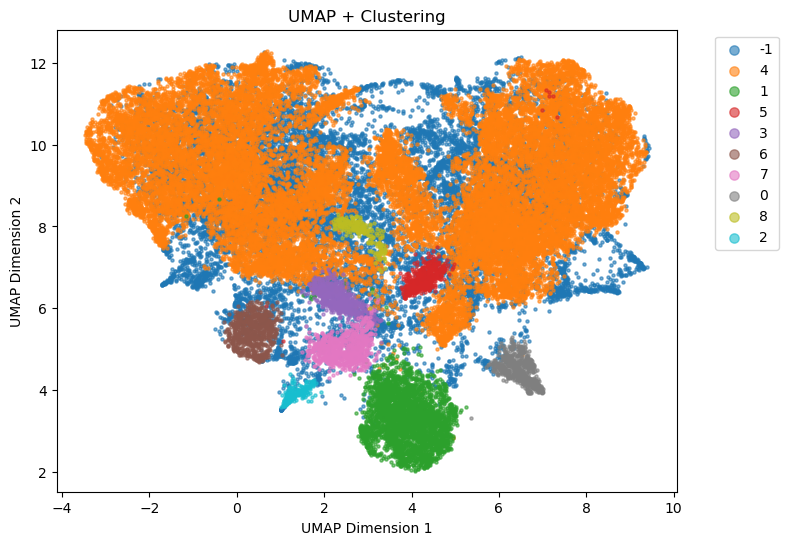

In [28]:
#Plot clusters

plt.figure(figsize=(8,6))
for label in df_umap['Cluster'].unique():
    subset = df_umap[df_umap['Cluster'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP + Clustering")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Regression Model

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [30]:
#get variables 
factors = model.get_factors() 
F = factors["group_1"]

#Get dependent var, change typ to any metadata column you wish to predict if factor values can predict
cell_names = F.index
cell_types = lrdata.obs["typ"]

#Sort both
cell_types = cell_types.sort_index()
F=  F.sort_index()

#Filter out any datapoint in response var that is not in features
filtered_cell_types = cell_types.loc[cell_types.index.isin(cell_names)]

### Create X and Y objects

In [31]:
F

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
c_3_100_100,1.467997,1.428154,0.601718,1.741933,0.610752,-1.014028,-0.155377,-0.664131,-1.662042,-0.964493,0.526167,0.062298,-1.387658,-0.360305,0.633427
c_3_100_1002,-0.433829,-0.544408,-0.428302,1.607468,0.399440,-0.067506,0.029958,-2.272489,-1.059495,-1.407803,1.029279,-0.454516,1.308380,1.742414,1.177225
c_3_100_1008,-0.032596,-0.555209,1.764547,-0.069978,1.279408,0.737005,0.543338,-0.001395,-0.547629,0.446007,-1.159160,-0.207769,0.564898,0.210725,-0.959553
c_3_100_1044,0.012791,0.513189,-0.640028,-0.493894,0.026911,0.029578,-0.142375,0.817455,-0.029327,-0.588597,-0.632339,0.292326,-0.545439,0.146718,0.849918
c_3_100_1105,-1.112208,-0.240500,-1.974717,-0.873821,-1.036993,-3.263009,-1.795862,-0.296085,-2.065710,3.269411,2.017301,-0.592953,-0.216110,-1.026710,-1.053291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c_3_9_96,-0.166135,-0.227024,0.341057,0.368312,-0.270796,-0.063452,0.691062,-0.078420,0.168004,1.480790,-2.143095,-1.097006,0.088211,0.499084,-0.000297
c_3_9_967,-0.694342,0.312914,-0.094730,0.240852,-0.234661,0.603289,-0.184455,0.371557,0.052532,-1.100293,-0.025229,-0.339984,0.613111,0.298723,0.088674
c_3_9_97,-2.842085,0.844733,1.705925,2.361417,-0.221913,-0.628122,-1.051472,-0.217022,-0.162999,1.510480,-0.566245,-0.239080,-0.602110,0.588784,2.872502
c_3_9_978,-0.414410,-0.411920,0.151855,0.231035,-0.226932,0.160372,-0.092369,-0.355398,0.241549,0.036667,-0.243425,-0.062894,0.179937,0.211185,0.118580


In [32]:
filtered_cell_types

c_3_100_100     231_CRC
c_3_100_1002    231_CRC
c_3_100_1008    231_CRC
c_3_100_1044    231_CRC
c_3_100_1105    231_CRC
                 ...   
c_3_9_96        231_CRC
c_3_9_967       231_REF
c_3_9_97        231_CRC
c_3_9_978       231_REF
c_3_9_981       231_REF
Name: typ, Length: 43372, dtype: category
Categories (3, object): ['231_CRC', '231_REF', '231_TVA']

In [33]:
X = F.values
y = filtered_cell_types.values  # labels

In [34]:
#Drop NaN labels
mask = ~pd.isna(y)
X = X[mask]
y = y[mask]

In [35]:
print(X.shape, y.shape)

(41257, 15) (41257,)


In [36]:
print("Min:", np.min(X))
print("Max:", np.max(X))
print("Mean:", np.mean(X))
print("Median:", np.median(X))
print("Std dev:", np.std(X))

Min: -5.6556435
Max: 5.862003
Mean: -0.006480406
Median: -0.008801397
Std dev: 0.83017904


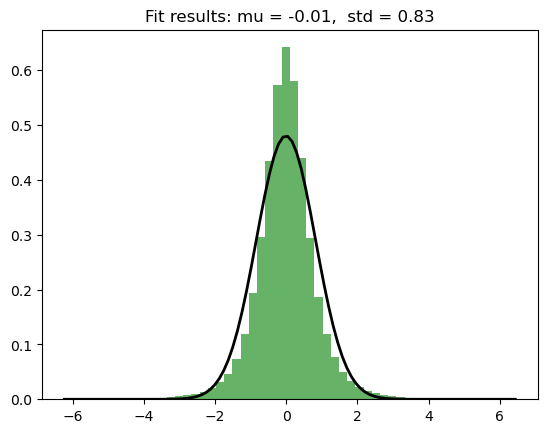

In [37]:
from scipy.stats import norm

data = X.flatten()

# histogram
plt.hist(data, bins=50, density=True, alpha=0.6, color='g')

# fit a normal
mu, std = norm.fit(data)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

plt.title(f"Fit results: mu = {mu:.2f},  std = {std:.2f}")
plt.show()


### Train multinomial logistic regression

In [38]:
# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [39]:
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=200,
    class_weight="balanced"
)

In [40]:
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

### Evaluate the model

In [41]:
# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.516965584100824

Classification Report:
               precision    recall  f1-score   support

     231_CRC       0.40      0.52      0.45      2839
     231_REF       0.22      0.43      0.29      1654
     231_TVA       0.78      0.53      0.63      7885

    accuracy                           0.52     12378
   macro avg       0.46      0.50      0.46     12378
weighted avg       0.61      0.52      0.55     12378



### AUC

In [42]:
from sklearn.metrics import roc_auc_score, roc_curve

#### 1. If threr are 2 classes only (REF vs. CRC)

AUC: 0.6078538535729829


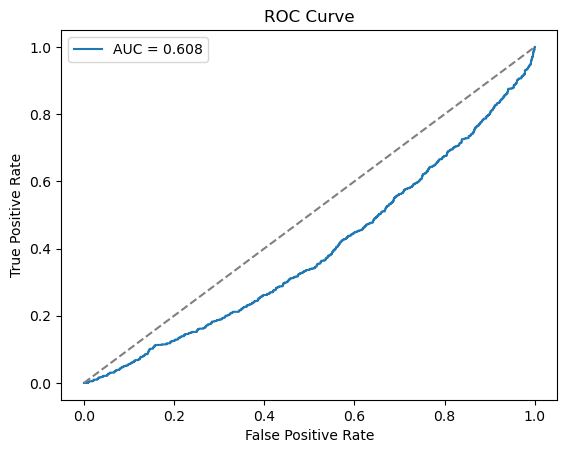

In [87]:
# Get predicted probabilities for the positive class (assume label "232_REF" is positive)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)


fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label="222_REF")
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#### 2. If classes are more than 2:

In [43]:
# Get class probabilities 
y_proba = clf.predict_proba(X_test)   # shape = (n_samples, 3)

# Compute macro-average AUC (each class equally weighted, good default)
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print(f"Multiclass ROC AUC (OvR, macro): {auc_macro:.4f}")

# You could also try weighted averaging (weights by class support):
auc_weighted = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
print(f"Multiclass ROC AUC (OvR, weighted): {auc_weighted:.4f}")


Multiclass ROC AUC (OvR, macro): 0.6727
Multiclass ROC AUC (OvR, weighted): 0.6834


# Map clusters to spatial 

In [44]:
df_umap

,UMAP1,UMAP2,Cluster,Conf,Label
c_3_2_8,4.285962,8.828702,-1,0.000000,231_REF
c_3_2_84,-0.022969,8.651846,4,1.000000,NaN
c_3_3_115,5.386215,7.554914,4,1.000000,231_TVA
c_3_3_990,0.940408,6.922901,4,1.000000,231_TVA
c_3_3_993,1.674403,7.424825,4,1.000000,231_TVA
...,...,...,...,...,...
c_3_78_984,0.519827,8.433059,-1,0.000000,231_CRC
c_3_79_533,3.658537,6.777260,4,0.932062,231_CRC
c_3_79_719,-0.427273,9.074049,4,0.939410,231_CRC
c_3_94_712,3.179355,6.436299,4,1.000000,231_CRC


In [45]:
clusters = df_umap['Cluster'].reindex(lrdata.obs_names)
print(f"Missing cluster labels: {clusters.isna().sum()}")

Missing cluster labels: 251757


In [46]:
lrdata.obs['Cluster'] = clusters.astype('category')

/scratch/jobs/37429356/ipykernel_2918570/1180120996.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


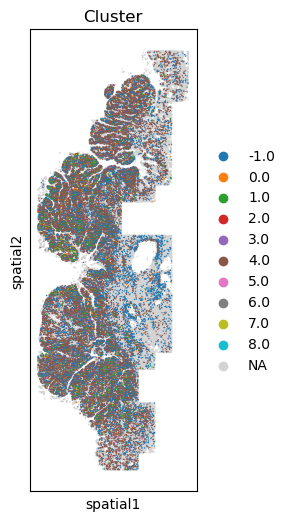

In [47]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.spatial(
    lrdata,
    color='Cluster',
    spot_size=40,
    ax=axes
)
plt.tight_layout()